In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import json, nltk

In [2]:
df_train = pd.read_csv("dati/train.csv")
df_test = pd.read_csv("dati/test.csv")

df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


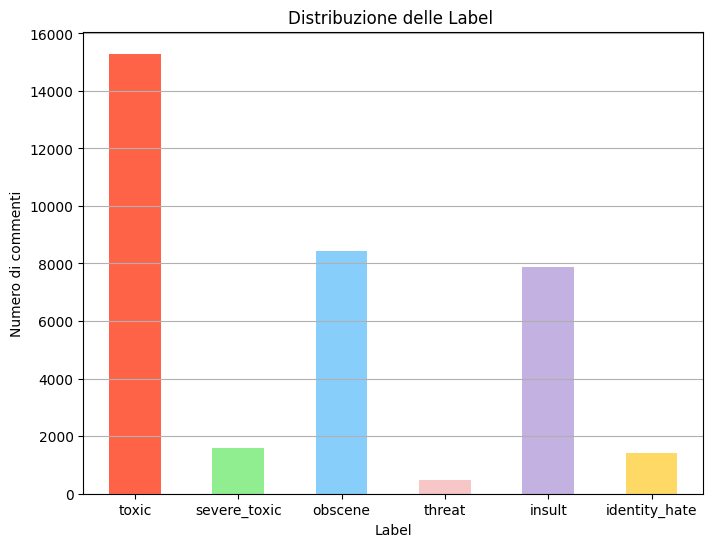

In [3]:
#contiamo quante volte ogni etichetta compare
cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df_train[cols].sum().sort_values(ascending = False)

sentiment_counts = df_train[cols].sum()

print(sentiment_counts)

colors = ['#ff6347', '#90ee90', '#87cefa', '#f7c6c7', '#c3b1e1', '#ffd966']

plt.figure(figsize =(8, 6))
sentiment_counts.plot(kind = 'bar', color = colors)

plt.title('Distribuzione delle Label ')
plt.xlabel('Label')
plt.ylabel('Numero di commenti')
plt.xticks(rotation = 0)
plt.grid(axis='y')
plt.show()

In [4]:
df_train['n_labels'] = df_train[cols].sum(axis = 1)
df_train['n_labels'].value_counts().sort_index()

n_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

In [5]:
df_train['length'] = df_train['comment_text'].str.len()
df_train['length'].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: length, dtype: float64

In [6]:
with open('dati/contractions.json', 'r') as f:
    contractions_dict = json.load(f)
contractions = contractions_dict['contractions']

In [7]:
from nltk.corpus import stopwords

nltk.download('stopwords')

std_stop = set(stopwords.words("english"))

#Teniamo alcune parole che sono fondamentali per differenziare tra insulti/minacce etc

words_uti = {
    "no", "not", "nor", "won't", "don't", "didn't", "can't",
    
    "i", "you", "your", "yours", "he", "she", "it",
    "we", "they", "them", "their", "his", "her",

    "am", "is", "are", "was", "were", "be", "been",
    "do", "does", "did",

    "will", "would", "should", "could", "must",

    "very", "too", "so"
}

light_stopwords = std_stop - words_uti


def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in light_stopwords])

def emoji(text):
    text = re.sub(r'(:\s?\)|:-\)|\(\s?:|\(-:|:\'\)|:o|:O|:0)', ' positiveemoji ', text)
    text = re.sub(r'(:\s?D|:-D|x-?D|X-?D)', ' positiveemoji ', text)
    text = re.sub(r'(<3|:\*)', ' positiveemoji ', text)
    text = re.sub(r'(;-?\)|;-?D|\(-?;|@-\))', ' positiveemoji ', text)

    text = re.sub(r'(:\s?\(|:-\(|\)\s?:|\)-:|:-/|:-\|)', ' negativeemoji ', text)
    text = re.sub(r'(:,\(|:\'\(|:"\()', ' negativeemoji ', text)

    return text

def expand_contractions(text):
    pattern = re.compile(r'\b(' + '|'.join(contractions.keys()) + r')\b')
    return pattern.sub(lambda x: contractions[x.group().lower()], text)

def clean_text(text):

    # Lowercase all
    text = text.lower()

    # Expand contractions BEFORE cleaning
    text = expand_contractions(text)

    # Remove usernames
    text = re.sub(r'@[^\s]+', '', text)

    # Remove URLs
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', " ", text)

    # Remove html entities
    text = re.sub(r'&quot;', " ", text)

    # Replace emojis
    text = emoji(text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', " ", text)

    # Compress repeated letters
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # Remove extra spaces
    text = re.sub(r'\s+', " ", text).strip()

    # Remove stopwords (light)
    text = remove_stopwords(text)

    return text

df_train['clean_comment'] = df_train['comment_text'].apply(clean_text)
df_train[['comment_text', 'clean_comment']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nicol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww he matches background colour I am seemingl...
2,"Hey man, I'm really not trying to edit war. It...",hey man I am really not trying edit war it it ...
3,"""\nMore\nI can't make any real suggestions on ...",i cannot make real suggestions improvement i w...
4,"You, sir, are my hero. Any chance you remember...",you sir are hero chance you remember page is


Iniziamo adesso l'analisi dati mediante Machine Learning, nel nostro caso conviene utilizzare un approccio TF-IDF.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_train['clean_comment']
y = df_train[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]

tfidf = TfidfVectorizer(
    max_features = 120000,
    ngram_range = (1,2),
    sublinear_tf = True  
)

X_vec = tfidf.fit_transform(X)
X_vec.shape  #E' la dimensione della nostra matrice

(159571, 120000)

In [10]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc as sk_auc

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state = 42
)

model = OneVsRestClassifier(LogisticRegression(max_iter = 200))
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

print("===== CLASSIFICATION REPORT (Logistic Regression) =====")
print(classification_report(y_test, y_pred_lr, target_names = y.columns))

y_prob_lr = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_prob_lr, average = "macro")

print("ROC-AUC macro:", auc)

===== CLASSIFICATION REPORT (Logistic Regression) =====
               precision    recall  f1-score   support

        toxic       0.93      0.56      0.70      3056
 severe_toxic       0.56      0.21      0.30       321
      obscene       0.93      0.57      0.71      1715
       threat       0.92      0.15      0.26        74
       insult       0.85      0.48      0.61      1614
identity_hate       0.69      0.11      0.19       294

    micro avg       0.90      0.51      0.65      7074
    macro avg       0.81      0.35      0.46      7074
 weighted avg       0.89      0.51      0.64      7074
  samples avg       0.05      0.04      0.04      7074

ROC-AUC macro: 0.9786274416630824


C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


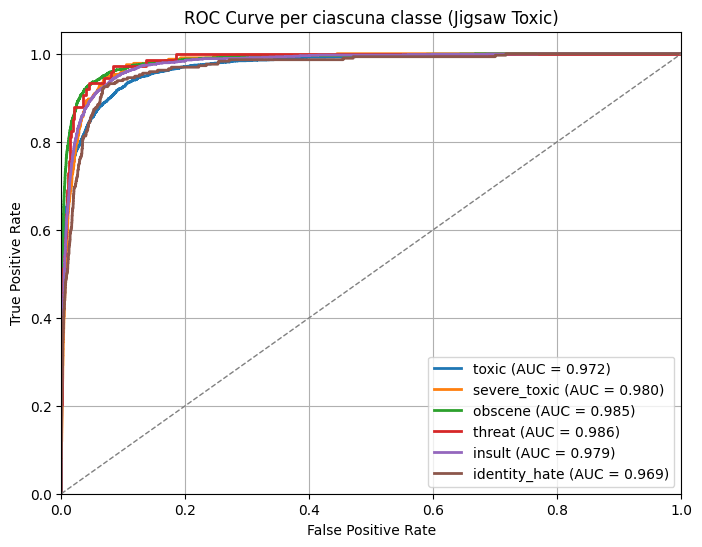

In [11]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_lr[:, i])
    roc_auc = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, lw = 2, label = f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per ciascuna classe (Jigsaw Toxic)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

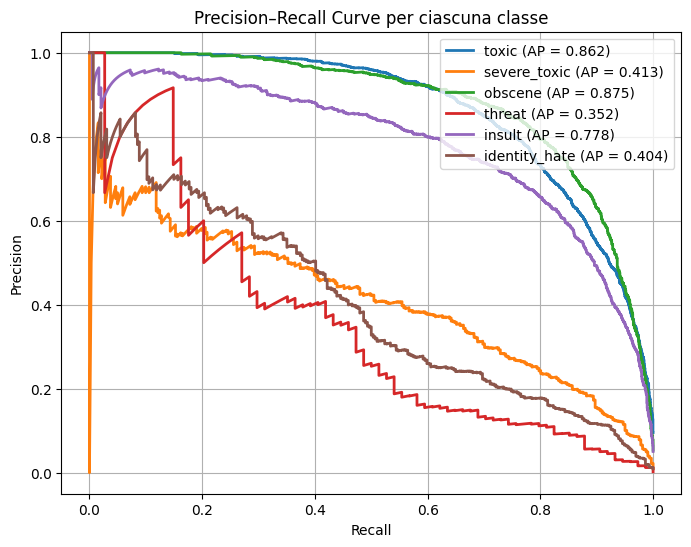

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_lr[:, i])
    ap = average_precision_score(y_test.iloc[:, i], y_prob_lr[:, i])
    
    plt.plot(recall, precision, lw = 2, label = f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve per ciascuna classe")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

In [13]:
from sklearn.naive_bayes import MultinomialNB

# Modello Naive Bayes con One-vs-Rest
nb_model = OneVsRestClassifier(MultinomialNB())

# Addestramento
nb_model.fit(X_train, y_train)

# Predizione
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)

# Report
print("===== CLASSIFICATION REPORT (NAIVE BAYES) =====")
print(classification_report(y_test, y_pred_nb, target_names = y.columns))

# ROC-AUC
auc_nb = roc_auc_score(y_test, y_prob_nb, average = "macro")
print("\nROC-AUC macro (Naive Bayes):", auc_nb)

===== CLASSIFICATION REPORT (NAIVE BAYES) =====
               precision    recall  f1-score   support

        toxic       0.97      0.37      0.54      3056
 severe_toxic       0.62      0.02      0.03       321
      obscene       0.95      0.30      0.46      1715
       threat       0.00      0.00      0.00        74
       insult       0.85      0.22      0.35      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.94      0.28      0.44      7074
    macro avg       0.57      0.15      0.23      7074
 weighted avg       0.87      0.28      0.42      7074
  samples avg       0.03      0.02      0.03      7074


ROC-AUC macro (Naive Bayes): 0.8903534905096441


C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\

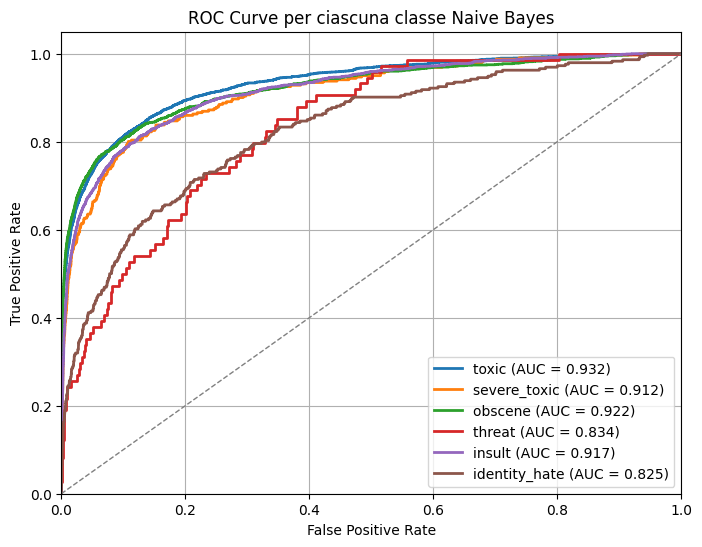

In [14]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_nb[:, i])
    roc_auc = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, lw = 2, label = f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', linewidth = 1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per ciascuna classe Naive Bayes")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

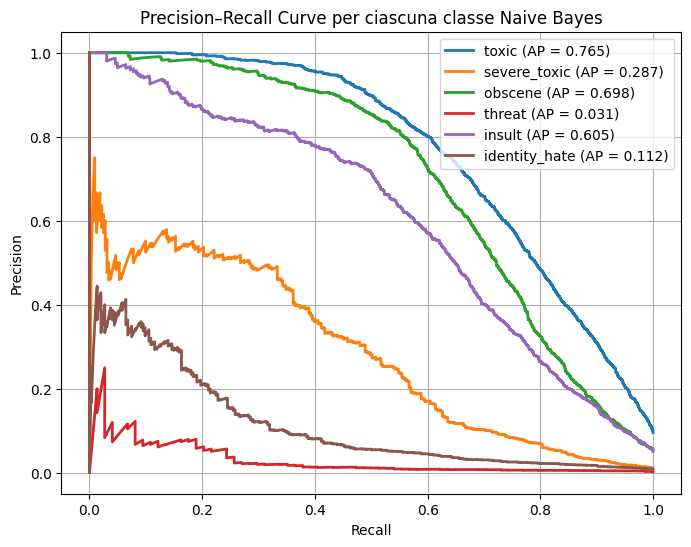

In [15]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_nb[:, i])
    ap = average_precision_score(y_test.iloc[:, i], y_prob_nb[:, i])
    
    plt.plot(recall, precision, lw = 2, label = f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve per ciascuna classe Naive Bayes")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

Facciamo adesso lo Stemming e ridefiniamo i 2 modelli per farne poi un confronto finale

In [17]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

def preprocess_with_stemming(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    text = clean_text(text)
    tokens = text.split()
    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in light_stopwords
    ]
    return " ".join(tokens)

df_train['clean_comment_stemm'] = df_train['clean_comment'].apply(preprocess_with_stemming)

In [18]:
df_train[['clean_comment_stemm', 'clean_comment']].head()

,clean_comment_stemm,clean_comment
0,explan edit made usernam hardcor metallica fan...,explanation edits made username hardcore metal...
1,aww he match background colour i am seem stuck...,aww he matches background colour I am seemingl...
2,hey man i am realli not tri edit war it it is ...,hey man I am really not trying edit war it it ...
3,i cannot make real suggest improv i wonder sec...,i cannot make real suggestions improvement i w...
4,you sir are hero chanc you rememb page is,you sir are hero chance you remember page is


In [19]:
tfidf_stem = TfidfVectorizer(
    max_features = 120000,
    ngram_range = (1,2),
    sublinear_tf = True  
)

X_stem = tfidf_stem.fit_transform(df_train['clean_comment_stemm'])

y = df_train[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stem, y, test_size = 0.2, random_state = 42)

lr_stem_model = OneVsRestClassifier(
    LogisticRegression(max_iter = 200)
)

lr_stem_model.fit(X_train_stem, y_train)

y_pred_lr_stem = lr_stem_model.predict(X_test)
y_prob_lr_stem = lr_stem_model.predict_proba(X_test_stem)

In [20]:
print("===== CLASSIFICATION REPORT (Logistic Regression con Stemming) =====")
print(classification_report(y_test, y_pred_lr_stem, target_names = y.columns))

auc_lr_stem = roc_auc_score(y_test, y_prob_lr_stem, average = "macro")

print("ROC-AUC macro:", auc_lr_stem)

===== CLASSIFICATION REPORT (Logistic Regression con Stemming) =====
               precision    recall  f1-score   support

        toxic       0.13      0.00      0.00      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.00      0.00      0.00      1715
       threat       0.00      0.00      0.00        74
       insult       0.00      0.00      0.00      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.11      0.00      0.00      7074
    macro avg       0.02      0.00      0.00      7074
 weighted avg       0.06      0.00      0.00      7074
  samples avg       0.00      0.00      0.00      7074

ROC-AUC macro: 0.9811177354430227


C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\

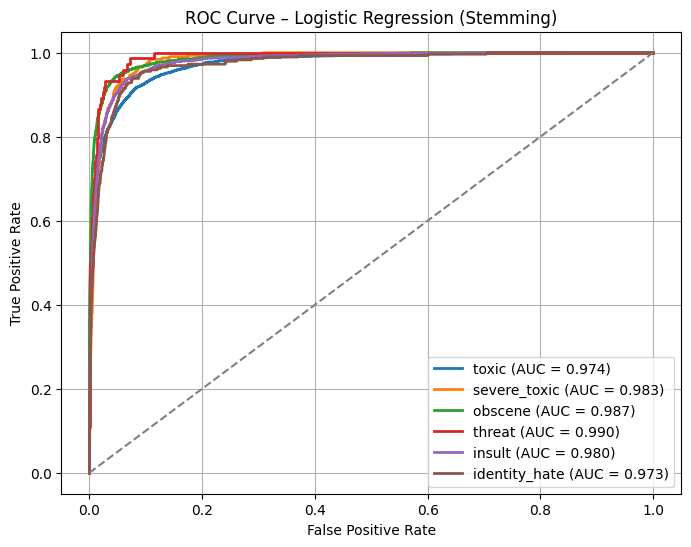

In [21]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_lr_stem[:, i])
    roc_auc_lr_stem = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, lw = 2, label = f"{class_name} (AUC = {roc_auc_lr_stem:.3f})")

plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression (Stemming)")
plt.legend()
plt.grid(True)
plt.show()

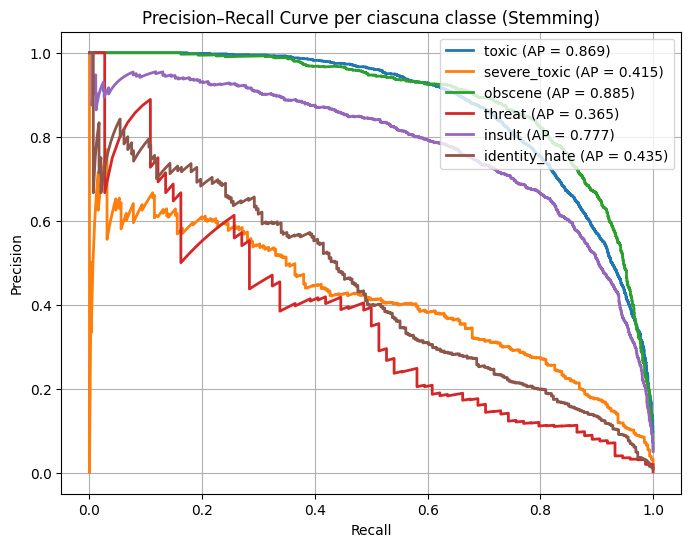

In [22]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_lr_stem[:, i])
    ap_lr_stem = average_precision_score(y_test.iloc[:, i], y_prob_lr_stem[:, i])
    
    plt.plot(recall, precision, lw = 2, label = f"{class_name} (AP = {ap_lr_stem:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve per ciascuna classe (Stemming)")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

In [23]:
# Modello Naive Bayes con One-vs-Rest
nb_model_stem = OneVsRestClassifier(MultinomialNB())

# Addestramento
nb_model_stem.fit(X_train_stem, y_train)

# Predizione
y_pred_nb_stem = nb_model_stem.predict(X_test_stem)
y_prob_nb_stem = nb_model_stem.predict_proba(X_test_stem)

# Report
print("===== CLASSIFICATION REPORT (Naive Bayes con Stemming) =====")
print(classification_report(y_test, y_pred_nb_stem, target_names = y.columns))

# ROC-AUC
auc_nb_stem = roc_auc_score(y_test, y_prob_nb_stem, average = "macro")
print("\nROC-AUC macro (Naive Bayes):", auc_nb_stem)

===== CLASSIFICATION REPORT (Naive Bayes con Stemming) =====
               precision    recall  f1-score   support

        toxic       0.97      0.36      0.52      3056
 severe_toxic       0.57      0.01      0.02       321
      obscene       0.95      0.30      0.46      1715
       threat       0.00      0.00      0.00        74
       insult       0.86      0.21      0.34      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.94      0.28      0.43      7074
    macro avg       0.56      0.15      0.22      7074
 weighted avg       0.87      0.28      0.42      7074
  samples avg       0.03      0.02      0.02      7074


ROC-AUC macro (Naive Bayes): 0.8922230154540634


C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\.conda\envs\notebook\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicol\

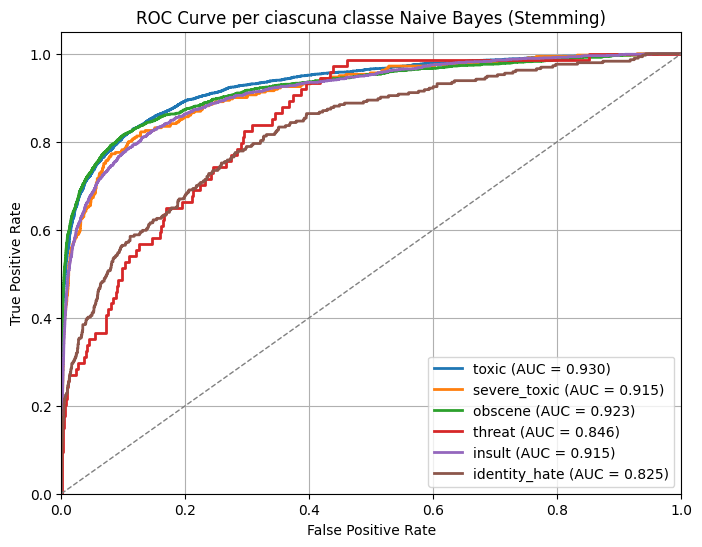

In [24]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_nb_stem[:, i])
    roc_auc_nb_stem = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, lw = 2, label = f"{class_name} (AUC = {roc_auc_nb_stem:.3f})")

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', linewidth = 1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per ciascuna classe Naive Bayes (Stemming)")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

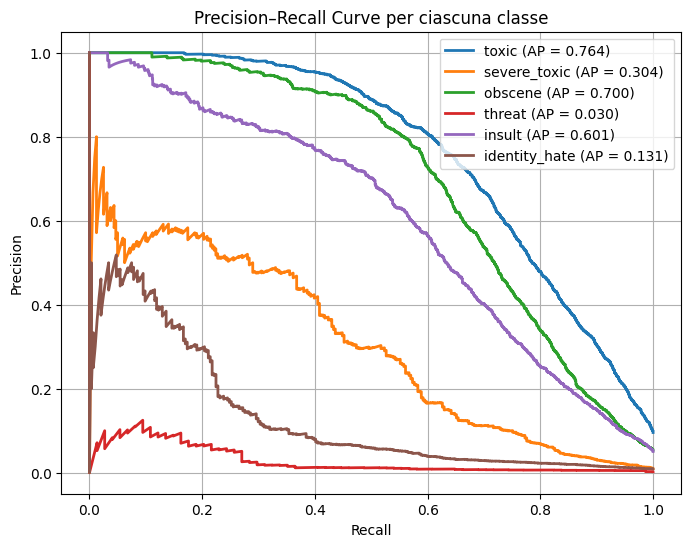

In [25]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(y.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_nb_stem[:, i])
    ap_nb_stem = average_precision_score(y_test.iloc[:, i], y_prob_nb_stem[:, i])
    
    plt.plot(recall, precision, lw = 2, label = f"{class_name} (AP = {ap_nb_stem:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve per ciascuna classe")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

In [26]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

results = {
    "Model": [],
    "F1 (macro)": [],
    "Precision (macro)": [],
    "Recall (macro)": [],
    "ROC-AUC (macro)": []
}

def add_results(model_name, y_test, y_pred, y_prob):
    results["Model"].append(model_name)
    results["F1 (macro)"].append(f1_score(y_test, y_pred, average = "macro"))
    results["Precision (macro)"].append(precision_score(y_test, y_pred, average = "macro", zero_division = 0))
    results["Recall (macro)"].append(recall_score(y_test, y_pred, average = "macro", zero_division = 0))
    results["ROC-AUC (macro)"].append(roc_auc_score(y_test, y_prob, average = "macro"))

# Aggiungo i modelli
add_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
add_results("Naive Bayes", y_test, y_pred_nb, y_prob_nb)
add_results("LogReg + Stemming", y_test, y_pred_lr_stem, y_prob_lr_stem)
add_results("NaiveBayes + Stemming", y_test, y_pred_nb_stem, y_prob_nb_stem)

results_df = pd.DataFrame(results)
results_df

,Model,F1 (macro),Precision (macro),Recall (macro),ROC-AUC (macro)
0,Logistic Regression,0.462942,0.813191,0.347583,0.978627
1,Naive Bayes,0.228749,0.565413,0.151155,0.890353
2,LogReg + Stemming,0.000217,0.022222,0.000109,0.981118
3,NaiveBayes + Stemming,0.224883,0.558749,0.147888,0.892223


Utilizziamo adesso il file Test.csv

In [28]:
df_test["clean_comment"] = df_test["comment_text"].apply(clean_text)

df_test["clean_comment_stem"] = df_test["clean_comment"].apply(preprocess_with_stemming)

X_test_tf = tfidf.fit_transform(df_test["clean_comment"])
X_test_lr  = tfidf.transform(df_test["clean_comment"])
X_test_tf_stem = tfidf_stem.fit_transform(df_test["clean_comment_stem"])
X_test_lr_stem  = tfidf.transform(df_test["clean_comment_stem"])

In [29]:
pred_lr = model.predict_proba(X_test_lr)
pred_nb = nb_model.predict(X_test_tf)

pred_lr_stem = lr_stem_model.predict_proba(X_test_lr_stem)
pred_nb_stem = nb_model_stem.predict(X_test_tf_stem)

In [71]:
# LR
pred_LR_df = pd.DataFrame({
    "comment_text": df_test["comment_text"],
    **{col: pred_lr[:, i] for i, col in enumerate(cols)}
})

# NB
pred_NB_df = pd.DataFrame({
    "comment_text": df_test["comment_text"],
    **{col: pred_nb[:, i] for i, col in enumerate(cols)}
})

# LR + stemming
pred_LR_stem_df = pd.DataFrame({
    "comment_text": df_test["comment_text"],
    **{col: pred_lr_stem[:, i] for i, col in enumerate(cols)}
})

# NB + stemming
pred_NB_stem_df = pd.DataFrame({
    "comment_text": df_test["comment_text"],
    **{col: pred_nb_stem[:, i] for i, col in enumerate(cols)}
})


===== Logistic Regression =====
toxic            9434.378773
severe_toxic     1060.166599
obscene          3749.145181
threat            357.927294
insult           3610.892818
identity_hate    1011.059143
dtype: float64


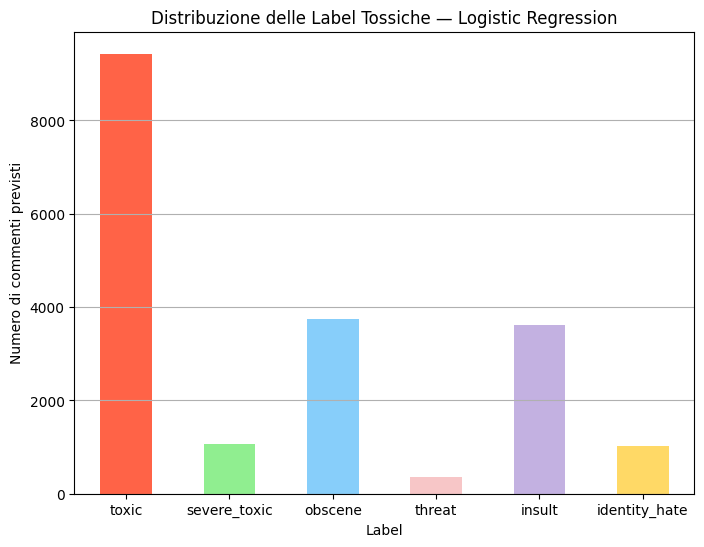


===== Naive Bayes =====
toxic            82996
severe_toxic     40832
obscene          74083
threat           23156
insult           71816
identity_hate    38443
dtype: int64


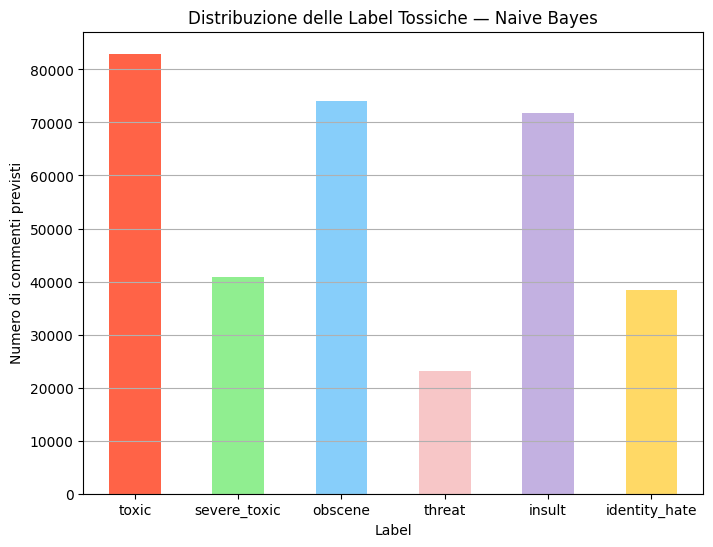


===== LR + Stemming =====
toxic            9633.936201
severe_toxic      950.142401
obscene          3677.724678
threat            362.766327
insult           3251.216270
identity_hate     922.531197
dtype: float64


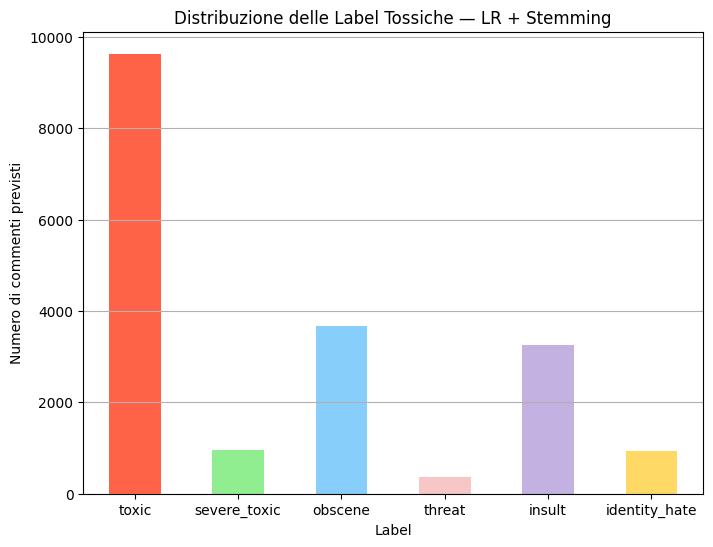


===== NB + Stemming =====
toxic            88059
severe_toxic     45335
obscene          78753
threat           26707
insult           76625
identity_hate    42573
dtype: int64


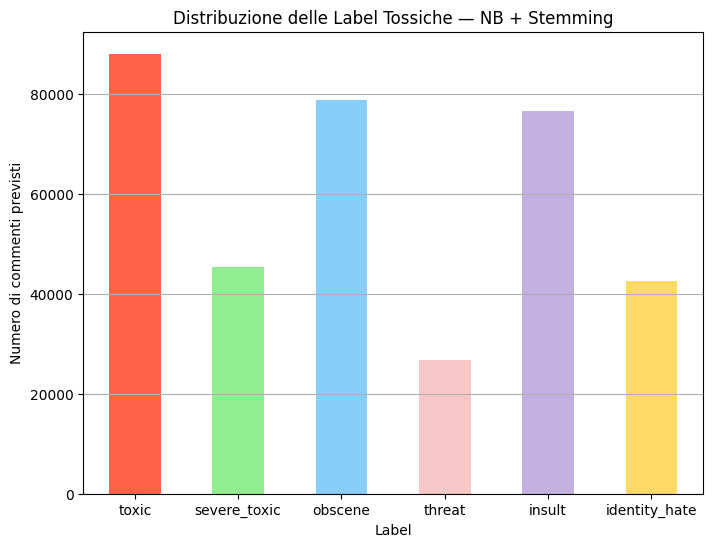

In [31]:
model_dfs = {
    "Logistic Regression": pred_LR_df,
    "Naive Bayes": pred_NB_df,
    "LR + Stemming": pred_LR_stem_df,
    "NB + Stemming": pred_NB_stem_df
}

colors = ['#ff6347', '#90ee90', '#87cefa', '#f7c6c7', '#c3b1e1', '#ffd966']

for model_name, df in model_dfs.items():

    # Conteggio dei commenti per ciascuna label
    label_counts = df[cols].sum()

    print(f"\n===== {model_name} =====")
    print(label_counts)

    plt.figure(figsize =(8, 6))
    label_counts.plot(kind = "bar", color = colors)

    plt.title(f"Distribuzione delle Label Tossiche — {model_name}")
    plt.xlabel("Label")
    plt.ylabel("Numero di commenti previsti")
    plt.xticks(rotation = 0)
    plt.grid(axis = 'y')
    plt.show()

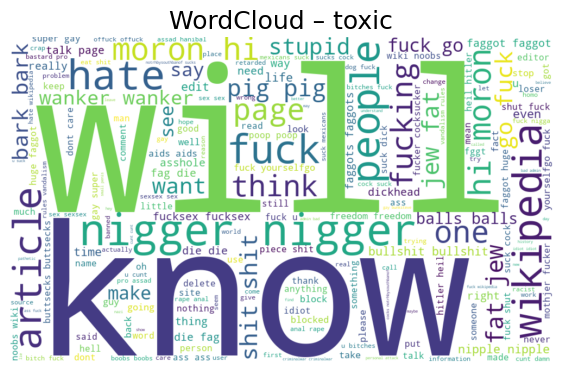

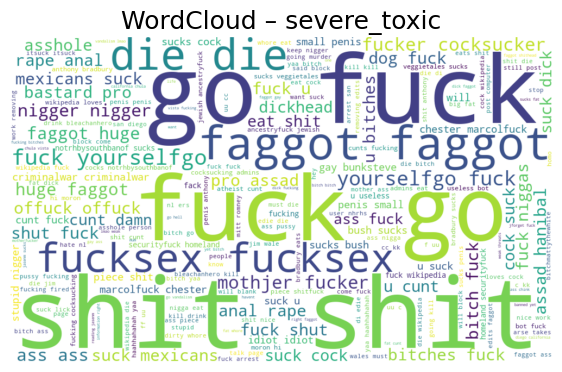

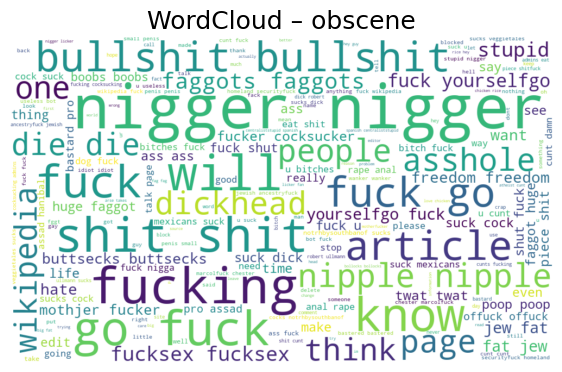

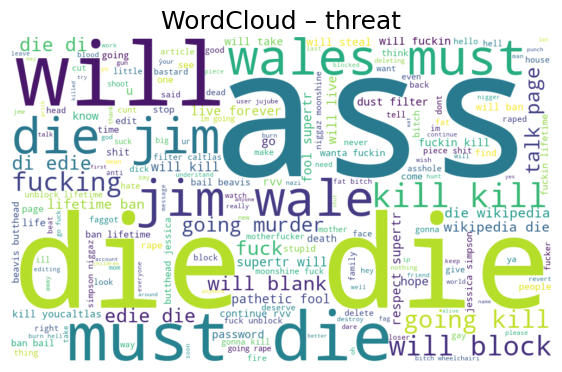

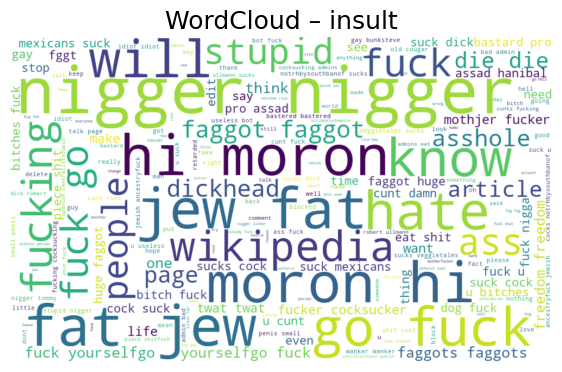

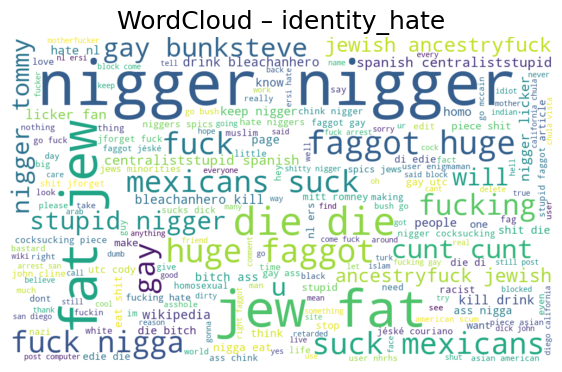

In [32]:
from wordcloud import WordCloud

for label in cols:
    text = " ".join(df_train[df_train[label] == 1]["clean_comment"].astype(str))

    wc = WordCloud(width = 1000, height = 600, background_color = "white").generate(text)

    plt.figure(figsize = (7, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud – {label}", fontsize = 18)
    plt.show()

In [33]:
from collections import Counter

for label in cols:
    words = " ".join(df_train[df_train[label] == 1]["clean_comment"]).split()
    counter = Counter(words).most_common(20)

    print(f"\n Le 20 parole più comuni per la label:{label}")
    for word, freq in counter:
        print(f"{word}: {freq}")


 Le 20 parole più comuni per la label:toxic
you: 39115
i: 20874
is: 15265
are: 10298
fuck: 9933
not: 9710
it: 9422
your: 9143
do: 6511
am: 4832
will: 3766
shit: 3623
be: 3583
like: 3512
wikipedia: 3432
nigger: 3299
fucking: 3289
suck: 3235
so: 3112
I: 3005

 Le 20 parole più comuni per la label:severe_toxic
you: 10754
fuck: 7304
i: 3525
suck: 2535
ass: 2115
your: 2056
shit: 1885
is: 1845
faggot: 1572
u: 1569
are: 1560
fucking: 1456
go: 1241
die: 1156
bitch: 1113
nigger: 1012
sucks: 961
cunt: 834
will: 779
it: 777

 Le 20 parole più comuni per la label:obscene
you: 23968
i: 10772
fuck: 9861
is: 7357
your: 5425
are: 5270
it: 4934
not: 4752
do: 3299
shit: 3214
fucking: 3192
suck: 3021
ass: 2851
nigger: 2726
u: 2272
go: 2148
will: 1952
bitch: 1797
am: 1779
wikipedia: 1707

 Le 20 parole più comuni per la label:threat
you: 2040
i: 1953
die: 1168
will: 911
ass: 772
your: 506
kill: 504
am: 373
going: 294
it: 247
not: 240
do: 208
I: 199
are: 191
block: 170
must: 167
fuck: 166
is: 159
jim: 158

In [34]:
#Lo facciamo con due perchè si capisce meglio la frequenza rispetto ad una singola parola
from sklearn.feature_extraction.text import CountVectorizer

for label in cols:
    comments = df_train[df_train[label] == 1]["clean_comment"]

    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=10)
    X = vectorizer.fit_transform(comments)

    ngrams = vectorizer.get_feature_names_out()
    counts = X.toarray().sum(axis=0)

    print(f"\nTOP 10 BIGRAMS per {label}")
    for ng, ct in sorted(zip(ngrams, counts), key=lambda x: -x[1]):
        print(f"{ng}: {ct}")


TOP 10 BIGRAMS per toxic
you are: 6174
fuck you: 4233
do not: 3032
it is: 2199
you fuck: 2092
nigger nigger: 2015
hate you: 1570
you you: 1478
moron hi: 1474
hi moron: 1472

TOP 10 BIGRAMS per severe_toxic
fuck you: 3442
you fuck: 1896
you are: 1233
you suck: 1168
ass ass: 1126
shit shit: 999
go fuck: 926
fuck go: 824
suck you: 730
faggot faggot: 712

TOP 10 BIGRAMS per obscene
fuck you: 4217
you are: 3356
you fuck: 2088
nigger nigger: 2015
do not: 1559
you suck: 1307
shit shit: 1146
go fuck: 1138
ass ass: 1127
it is: 1057

TOP 10 BIGRAMS per threat
ass ass: 678
die die: 637
you will: 356
am going: 263
kill you: 245
you am: 236
must die: 160
jim wales: 157
die jim: 156
wales must: 156

TOP 10 BIGRAMS per insult
you are: 4094
fuck you: 3531
nigger nigger: 1707
you fuck: 1504
do not: 1438
you suck: 1290
moron hi: 1273
hi moron: 1270
jew fat: 1234
fat jew: 1226

TOP 10 BIGRAMS per identity_hate
nigger nigger: 1901
jew fat: 1234
fat jew: 1226
die die: 634
is gay: 477
you are: 472
huge fag

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def get_lda_topics(texts, n_topics = 5, light_stopwords ='english'):
    
    tfidf_vectorizer = TfidfVectorizer(
        stop_words= light_stopwords,
        max_df = 0.85,
        min_df = 3,
        ngram_range =(1, 2)
    )

    X = tfidf_vectorizer.fit_transform(texts)

    # Modello LDA
    lda_model = LatentDirichletAllocation(
        n_components = n_topics,
        random_state = 42,
        learning_method = "online"
    )
    
    lda_model.fit(X)

    topics = []
    feature_names = tfidf_vectorizer.get_feature_names_out()

    for idx, topic in enumerate(lda_model.components_):
        top_keywords = [feature_names[i] for i in topic.argsort()[-10:]]
        topics.append(top_keywords)

    return topics

In [36]:
lda_results = {}

for label in cols:
    texts = df_train[df_train[label] == 1]["clean_comment"]

    if len(texts) < 50:
        print(f"Troppi pochi testi per la classe {label}")
        continue

    lda_results[label] = get_lda_topics(texts, n_topics = 4)

# Stampa risultati
for label, topics in lda_results.items():
    print(f"\n====={label} =====")
    for i, t in enumerate(topics):
        print(f"Topic {i+1}: {t}")


=====toxic =====
Topic 1: ['annoying', 'address', 'bloody', 'disgusting', 'son bitch', 'hate', 'wtf', 'son', 'ha', 'penis']
Topic 2: ['fuck', 'likes', 'mother fucker', 'youre', 'douchebag', 'asshole', 'douche', 'scum', 'unblock', 'fucker']
Topic 3: ['think', 'did', 'stop', 'article', 'talk', 'know', 'people', 'page', 'like', 'wikipedia']
Topic 4: ['dick', 'cunt', 'ass', 'gay', 'shit', 'faggot', 'fucking', 'bitch', 'suck', 'fuck']

=====severe_toxic =====
Topic 1: ['aww', 'idiot', 'niggas', 'urself', 'anti', 'loving', 'cock', 'ha', 'american', 'kill']
Topic 2: ['people', 'page', 'like', 'know', 'faggot', 'wikipedia', 'shit', 'fuck fuck', 'fucking', 'fuck']
Topic 3: ['piece', 'asshole', 'cunt', 'fucking', 'shit', 'dick', 'ass', 'fuck', 'suck', 'bitch']
Topic 4: ['little bitch', 'cking', 'fucking moron', 'ck', 'butt', 'fucken', 'little', 'fuck', 'moron', 'penis']

=====obscene =====
Topic 1: ['know', 'asshole', 'ass', 'page', 'wikipedia', 'stupid', 'shit', 'like', 'fuck', 'fucking']
Topi